# Shill Bidding Detection

This notebook trains a classifier to detect shill bidding (fake bids placed to
artificially inflate an auction's price) using the UCI *Shill Bidding Dataset*.

**Pipeline:** load & explore data → preprocess → train Logistic Regression and
Random Forest → evaluate → export the trained model for production use in the
Node.js backend (`fraudDetection.js`).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve


## 1. Load the dataset

In [3]:
df = pd.read_csv("Shill_Bidding_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (6321, 13)


,Record_ID,Auction_ID,Bidder_ID,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
0,1,732,_***i,0.200000,0.400000,0.0,0.000028,0.0,0.993593,0.000028,0.666667,5,0
1,2,732,g***r,0.024390,0.200000,0.0,0.013123,0.0,0.993593,0.013123,0.944444,5,0
2,3,732,t***p,0.142857,0.200000,0.0,0.003042,0.0,0.993593,0.003042,1.000000,5,0
3,4,732,7***n,0.100000,0.200000,0.0,0.097477,0.0,0.993593,0.097477,1.000000,5,0
4,5,900,z***z,0.051282,0.222222,0.0,0.001318,0.0,0.000000,0.001242,0.500000,7,0


In [6]:
print(df.dtypes)
print()
print(df.isnull().sum())

Record_ID                   int64
Auction_ID                  int64
Bidder_ID                     str
Bidder_Tendency           float64
Bidding_Ratio             float64
Successive_Outbidding     float64
Last_Bidding              float64
Auction_Bids              float64
Starting_Price_Average    float64
Early_Bidding             float64
Winning_Ratio             float64
Auction_Duration            int64
Class                       int64
dtype: object

Record_ID                 0
Auction_ID                0
Bidder_ID                 0
Bidder_Tendency           0
Bidding_Ratio             0
Successive_Outbidding     0
Last_Bidding              0
Auction_Bids              0
Starting_Price_Average    0
Early_Bidding             0
Winning_Ratio             0
Auction_Duration          0
Class                     0
dtype: int64


## 2. Class Balance

In [12]:
counts = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True)*100
print("Class Counts:", counts)
print()
print("Class Percentage:")
print(pct.round(2))

Class Counts: Class
0    5646
1     675
Name: count, dtype: int64

Class Percentage:
Class
0    89.32
1    10.68
Name: proportion, dtype: float64


**This shows shill bidding is a rare problem. Most bids are legitimate.** <br>
**Class 0:** Legit <br>
**CLass 1:** Fraud/Shill Bids

/tmp/ipykernel_26851/516455792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=ax, palette=["#1F6E5C", "#A8412B"])
/tmp/ipykernel_26851/516455792.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normal(0)', 'Shill(1)'])


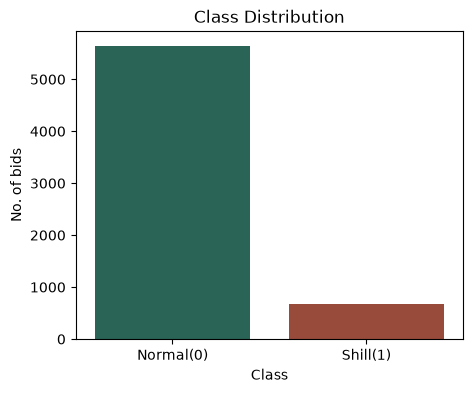

In [13]:
fig,ax = plt.subplots(figsize=(5,4))
sns.countplot(x='Class', data=df, ax=ax, palette=["#1F6E5C", "#A8412B"])
ax.set_xticklabels(['Normal(0)', 'Shill(1)'])
ax.set_title('Class Distribution')
ax.set_ylabel('No. of bids')
plt.show()

## 3. Feature overview

The dataset features 9 predictive features about a bidder's behavior within an auction (not raw bid events):

| Feature | Meaning |
|---|---|
| `Bidder_Tendency` | How concentrated a bidder's activity is across sellers |
| `Bidding_Ratio` | Bidder's share of total bids in the auction |
| `Successive_Outbidding` | Whether the bidder repeatedly re-bid right after being outbid |
| `Last_Bidding` | Normalized time of the bidder's last bid before auction end |
| `Auction_Bids` | Normalized total bid count in the auction |
| `Starting_Price_Average` | Starting price relative to average |
| `Early_Bidding` | Normalized time of the bidder's earliest bid |
| `Winning_Ratio` | Bidder's historical win rate |
| `Auction_Duration` | Auction length in days |


In [16]:
features = ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding',
            'Winning_Ratio', 'Auction_Duration']
df[features + ['Class']].describe()

,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
count,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000
mean,0.142541,0.127670,0.103781,0.463119,0.231606,0.472821,0.430683,0.367731,4.615093,0.106787
std,0.197084,0.131530,0.279698,0.380097,0.255252,0.489912,0.380785,0.436573,2.466629,0.308867
min,0.000000,0.011765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.027027,0.043478,0.000000,0.047928,0.000000,0.000000,0.026620,0.000000,3.000000,0.000000
50%,0.062500,0.083333,0.000000,0.440937,0.142857,0.000000,0.360104,0.000000,5.000000,0.000000
75%,0.166667,0.166667,0.000000,0.860363,0.454545,0.993593,0.826761,0.851852,7.000000,0.000000
max,1.000000,1.000000,1.000000,0.999900,0.788235,0.999935,0.999900,1.000000,10.000000,1.000000


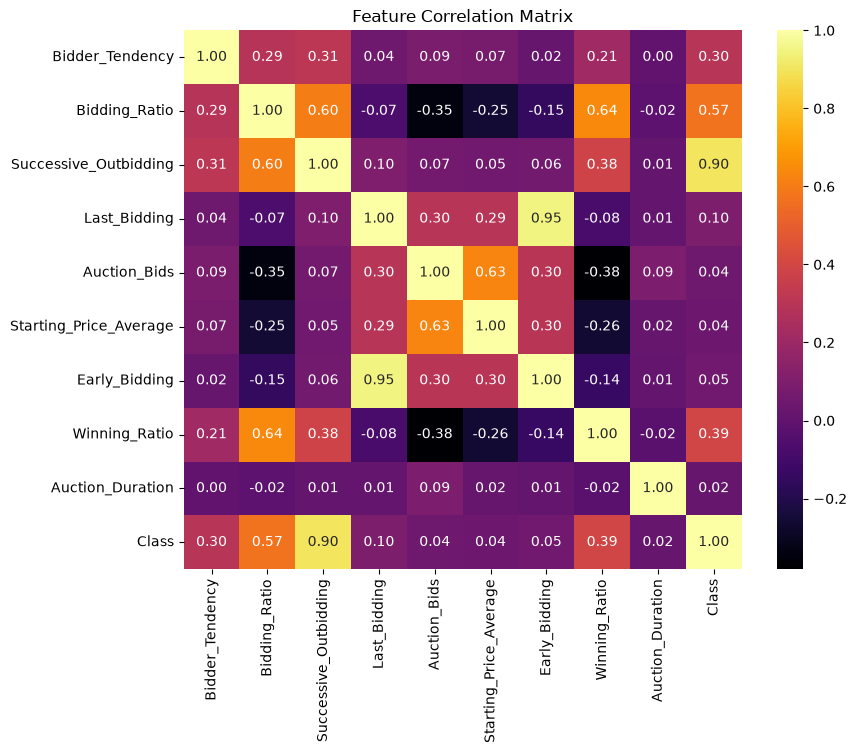

In [21]:
fig,ax = plt.subplots(figsize=(9,7))
corr = df[features + ['Class']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='inferno', ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.show()


`Successive_Outbidding`, `Bidding_Ratio` and `Winning_Ratio` show the strongest correlation
with `Class` — consistent with how shill bidding actually works: a shill
repeatedly re-tops bids to drive the price up, but rarely intends to win.


## 4. Train/Test Split and Scaling

In [ ]:
X = df[features].values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 5056  Test size: 1265


## 5. Model 1: Logistic Regression

In [ ]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_train_s, y_train)
pred = logreg.predict(X_test_s)
proba = logreg.predict_proba(X_test_s)[:, 1] 
# Calculates the exact probability output (between 0.0 and 1.0) of a sample being Class 1
# The [:, 1] slice selects the second column (probability of fraud) while ignoring column 0
print(classification_report(y_test, pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, proba))
# ROC-AUC: 0.996, it means that 99.6% of the time, if you compare a random fraudster and a random normal user,
# your model correctly gave the fraudster a higher risk score.
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))


[0 0 0 ... 0 0 0]
              precision    recall  f1-score   support

           0      1.000     0.980     0.990      1130
           1      0.854     1.000     0.922       135

    accuracy                          0.982      1265
   macro avg      0.927     0.990     0.956      1265
weighted avg      0.984     0.982     0.982      1265

ROC-AUC: 0.996322517207473
Confusion matrix:
[[1107   23]
 [   0  135]]


## 6, Model 2: Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))

print("Confusion matrix:")
print(confusion_matrix(y_test, pred_rf))


              precision    recall  f1-score   support

           0      1.000     0.982     0.991      1130
           1      0.871     1.000     0.931       135

    accuracy                          0.984      1265
   macro avg      0.935     0.991     0.961      1265
weighted avg      0.986     0.984     0.985      1265

ROC-AUC: 0.9998820058997051
Confusion matrix:
[[1110   20]
 [   0  135]]


## 7. ROC Curve Comparison

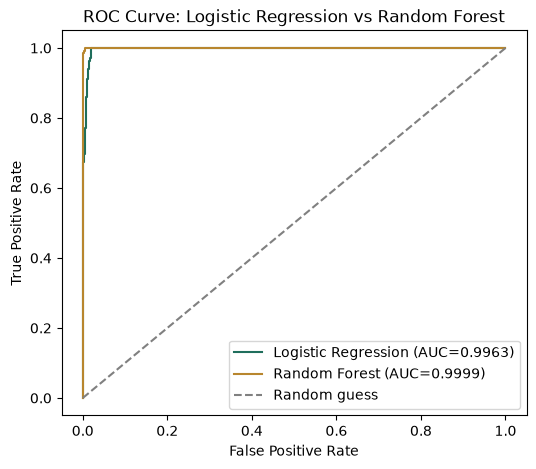

In [32]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, proba):.4f})', color='#1F6E5C')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, proba_rf):.4f})', color='#B8862E')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Logistic Regression vs Random Forest')
ax.legend()
plt.show()


## 8. Export the production model

In [ ]:
import json

model_export = {
    "features": features,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "coef": logreg.coef_[0].tolist(),
    "intercept": float(logreg.intercept_[0]),
    "threshold": 0.5
}

with open("shill_model.json", "w") as f:
    json.dump(model_export, f, indent=2)

print("Exported shill_model.json")
print(json.dumps(model_export, indent=2)[:400], "...")
